In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, log_loss
import matplotlib.pyplot as plt

# Importación de TabPFN para clasificación
# Nota: Requiere tener instalado el paquete: pip install tabpfn
from tabpfn import TabPFNClassifier

In [2]:
# 1. CONFIGURACIÓN DE SEMILLAS PARA REPRODUCIBILIDAD ACADÉMICA
np.random.seed(42)
tf.random.set_seed(42)

# Carga de datos
train_df = pd.read_csv('data/train.csv')
test_df = pd.read_csv('data/test.csv')

In [5]:
# Definir la variable objetivo (reemplaza 'target' por el nombre real de tu columna objetivo)
target_column = 'Transported' 

X = train_df.drop(columns=[target_column])
y = train_df[target_column]

# Identificar columnas numéricas y categóricas
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X.select_dtypes(include=['object', 'category']).columns

# Crear transformadores
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Combinar preprocesadores
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# Dividir en entrenamiento y validación
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

--- CONSTRUYENDO REGULARIZED TABULAR RESNET (V5) ---
Epoch 1/60
205/218 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7168 - loss: 1.4034
Epoch 1: val_loss improved from None to 1.26373, saving model to best_resnet_v5_model.keras

Epoch 1: finished saving model to best_resnet_v5_model.keras
218/218 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.7193 - loss: 1.3986 - val_accuracy: 0.7665 - val_loss: 1.2637 - learning_rate: 0.0010
Epoch 2/60
217/218 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7692 - loss: 1.2503
Epoch 2: val_loss improved from 1.26373 to 1.15920, saving model to best_resnet_v5_model.keras

Epoch 2: finished saving model to best_resnet_v5_model.keras
218/218 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7691 - loss: 1.2502 - val_accuracy: 0.7792 - val_loss: 1.1592 - learning_rate: 0.0010
Epoch 3/60
216/218 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7771 - loss: 1.1436
Epoch 3: val_loss improved from 1.15920 to 1.06863, saving model to best_resnet_v5_model.keras



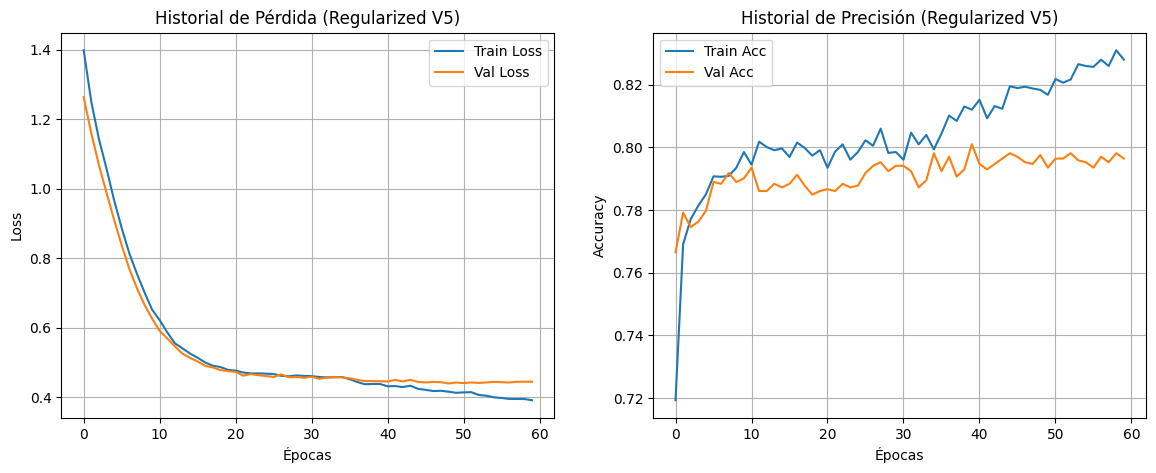

In [6]:
# 2. PIPELINE DE INGENIERÍA DE VARIABLES (Consistente con versiones previas)
def preprocess_features(df):
    df = df.copy()
    # Gastos consolidados
    spend_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
    df[spend_cols] = df[spend_cols].fillna(0)
    df['TotalSpend'] = df[spend_cols].sum(axis=1)
    df['HasSpented'] = (df['TotalSpend'] > 0).astype(str)
    
    # Datos de grupo y cabina
    df['Group'] = df['PassengerId'].apply(lambda x: x.split('_')[0] if pd.notnull(x) else '0000')
    group_sizes = df['Group'].value_counts()
    df['GroupSize'] = df['Group'].map(group_sizes)
    df['IsAlone'] = (df['GroupSize'] == 1).astype(str)
    
    df['Cabin'] = df['Cabin'].fillna('U/0/U')
    df['Cabin_Deck'] = df['Cabin'].apply(lambda x: x.split('/')[0])
    df['Cabin_Side'] = df['Cabin'].apply(lambda x: x.split('/')[-1])
    return df

train_processed = preprocess_features(train_df)
test_processed = preprocess_features(test_df)

num_features = ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'TotalSpend', 'GroupSize']
cat_features = ['HomePlanet', 'CryoSleep', 'Destination', 'VIP', 'Cabin_Deck', 'Cabin_Side', 'HasSpented', 'IsAlone']

num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', num_transformer, num_features),
    ('cat', cat_transformer, cat_features)
])

# Splits de validación
X = train_processed[num_features + cat_features]
y = train_processed['Transported'].astype(int).values

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

X_train_trans = preprocessor.fit_transform(X_train)
X_val_trans = preprocessor.transform(X_val)
X_test_trans = preprocessor.transform(test_processed[num_features + cat_features])

# 3. DISEÑO DE LA ARQUITECTURA RESIDUAL ALTAMENTE REGULARIZADA

print("--- CONSTRUYENDO REGULARIZED TABULAR RESNET (V5) ---")

input_dim = X_train_trans.shape[1]
inputs = layers.Input(shape=(input_dim,), name="Input_Features")

# Factor de regularización L2 más restrictivo
l2_reg = keras.regularizers.l2(0.0015)

# Capa de proyección inicial
x = layers.Dense(128, activation='relu', kernel_regularizer=l2_reg)(inputs)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.4)(x)  # Incrementado de 0.3 a 0.4 para combatir overfitting

# --- BLOQUE RESIDUAL 1 (128 Neuronas) ---
res1 = layers.Dense(128, activation='relu', kernel_regularizer=l2_reg)(x)
res1 = layers.BatchNormalization()(res1)
res1 = layers.Dropout(0.4)(res1)
res1 = layers.Dense(128, activation='relu', kernel_regularizer=l2_reg)(res1)
res1 = layers.BatchNormalization()(res1)
x = layers.add([x, res1]) 

# --- BLOQUE RESIDUAL 2 (64 Neuronas) ---
x_proj = layers.Dense(64, activation='relu', kernel_regularizer=l2_reg)(x)
x_proj = layers.BatchNormalization()(x_proj)

res2 = layers.Dense(64, activation='relu', kernel_regularizer=l2_reg)(x_proj)
res2 = layers.BatchNormalization()(res2)
res2 = layers.Dropout(0.3)(res2)
res2 = layers.Dense(64, activation='relu', kernel_regularizer=l2_reg)(res2)
res2 = layers.BatchNormalization()(res2)
x = layers.add([x_proj, res2])

# --- CAPA DE SALIDA CON REGULARIZACIÓN SÓLIDA ---
x = layers.Dense(32, activation='relu', kernel_regularizer=l2_reg)(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.25)(x)

outputs = layers.Dense(1, activation='sigmoid', name="Output_Layer")(x)

model = keras.Model(inputs=inputs, outputs=outputs, name="Regularized_Tabular_ResNet")

# 4. ENTRENAMIENTO CON OPTIMIZACIÓN SUAVE

# Learning rate inicial de 0.001 (más conservador que el 0.003 de la v4)
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Callback para guardar el mejor modelo absoluto basándose en la pérdida de validación
checkpoint = keras.callbacks.ModelCheckpoint(
    filepath='best_resnet_v5_model.keras',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

lr_decay = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', 
    factor=0.5, 
    patience=3, 
    verbose=1,
    min_lr=1e-5
)

early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=12,
    restore_best_weights=True
)

history = model.fit(
    X_train_trans, y_train,
    validation_data=(X_val_trans, y_val),
    epochs=60,
    batch_size=32,
    callbacks=[early_stopping, lr_decay, checkpoint],
    verbose=1
)

# 5. GRAFICAR CURVAS DE APRENDIZAJE PARA EL REPORTE

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(history.history['loss'], label='Train Loss')
ax1.plot(history.history['val_loss'], label='Val Loss')
ax1.set_title('Historial de Pérdida (Regularized V5)')
ax1.set_xlabel('Épocas')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True)

ax2.plot(history.history['accuracy'], label='Train Acc')
ax2.plot(history.history['val_accuracy'], label='Val Acc')
ax2.set_title('Historial de Precisión (Regularized V5)')
ax2.set_xlabel('Épocas')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True)
plt.savefig('learning_curves_v5.png')
plt.show()

In [10]:
print("--- ENTRENANDO CLASIFICADOR TABPFN (V3 CHECKPOINT LOCAL) ---")

# Ruta exacta corregida según tu Traceback
checkpoint_path = r"C:\Users\Alumne_mati1\Documents\machine_learning_course_cifo_2026\tabpfn-driver\tabpfn-v3-classifier-v3_20260417_binary.ckpt"

# Inicializar TabPFNClassifier saltándonos el límite de muestras en CPU
tabpfn_classifier = TabPFNClassifier(
    model_path=checkpoint_path,
    device='cpu',
    ignore_pretraining_limits=True  # <-- Esto desactiva el bloqueo de >1000 muestras en CPU
)

# Crear el pipeline integrando el preprocesador y TabPFN
tabpfn_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', tabpfn_classifier)
])

# Ajustar el pipeline con tus datos (ahora no debería fallar por el límite de muestras)
tabpfn_pipeline.fit(X_train, y_train)

# Realizar predicciones en el set de validación
y_pred = tabpfn_pipeline.predict(X_val)
y_pred_proba = tabpfn_pipeline.predict_proba(X_val)

# Evaluar el rendimiento
accuracy = accuracy_score(y_val, y_pred)
loss = log_loss(y_val, y_pred_proba)

print(f"Exactitud (Accuracy) en Validación: {accuracy:.4f}")
print(f"Pérdida Logarítmica (Log Loss) en Validación: {loss:.4f}")
print("\nReporte de Clasificación:")
print(classification_report(y_val, y_pred))

--- ENTRENANDO CLASIFICADOR TABPFN (V3 CHECKPOINT LOCAL) ---
Exactitud (Accuracy) en Validación: 0.8005
Pérdida Logarítmica (Log Loss) en Validación: 0.4078

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.82      0.77      0.79       861
           1       0.78      0.83      0.81       878

    accuracy                           0.80      1739
   macro avg       0.80      0.80      0.80      1739
weighted avg       0.80      0.80      0.80      1739



In [13]:
# 5. GENERACIÓN DEL ARCHIVO SUBMISSION_TABPFN.CSV
print("\n--- GENERANDO SUBMISSION_TABPFN.CSV ---")

# 1. Copiar el test para no alterar el original
X_test = test_df.copy()

# =========================================================================
# ⚠️ ¡IMPORTANTE! APLICA AQUÍ LA INGENIERÍA DE CARACTERÍSTICAS A X_TEST
# (Asegúrate de que estas operaciones coincidan exactamente con tu entrenamiento)
# =========================================================================

# Ejemplo de cómo podrías haber creado 'GroupSize' y 'IsAlone':
# X_test['GroupSize'] = X_test['PassengerId'].apply(lambda x: ... )
# X_test['IsAlone'] = ...

# Ejemplo de cómo podrías haber creado 'TotalSpend' y 'HasSpented':
# gaston_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
# X_test['TotalSpend'] = X_test[gaston_cols].sum(axis=1)
# X_test['HasSpented'] = X_test['TotalSpend'] > 0

# Ejemplo de cómo podrías haber creado 'Cabin_Deck' y 'Cabin_Side':
# X_test['Cabin_Deck'] = X_test['Cabin'].apply(lambda x: str(x).split('/')[0] if pd.notna(x) else np.nan)
# X_test['Cabin_Side'] = X_test['Cabin'].apply(lambda x: str(x).split('/')[-1] if pd.notna(x) else np.nan)

# =========================================================================
# Una vez aplicados los mismos pasos de Feature Engineering, quitamos 'PassengerId'
# =========================================================================
X_test = X_test.drop(columns=['PassengerId'], errors='ignore')

# 2. Hacemos las predicciones usando directamente nuestro Pipeline unificado
# (Ahora sí encontrará las columnas 'Cabin_Side', 'TotalSpend', etc.)
test_preds_proba = tabpfn_pipeline.predict_proba(X_test)[:, 1]

# 3. Convertimos las probabilidades a valores booleanos para la competición (True / False)
test_preds_boolean = (test_preds_proba > 0.5).astype(bool)

# 4. Creamos el DataFrame final con el formato requerido por el dataset de Spaceship Titanic
submission_df = pd.DataFrame({
    'PassengerId': test_df['PassengerId'],
    'Transported': test_preds_boolean
})

# 5. Exportamos a CSV sin el índice de pandas
submission_df.to_csv('submission_6.csv', index=False)

print("✅ ¡Archivo 'submission_6.csv' guardado con éxito!")
print("\nDistribución de las predicciones en el conjunto de test:")
print(submission_df['Transported'].value_counts())


--- GENERANDO SUBMISSION_TABPFN.CSV ---


ValueError: columns are missing: {'Cabin_Side', 'TotalSpend', 'IsAlone', 'HasSpented', 'Cabin_Deck', 'GroupSize'}